In [1]:
import scanpy as sc

import sys
sys.path.append('../../1_figure_CL_proof_of_concept/code/')
import utils_00 as gf_utils

large_data_dir = gf_utils.large_data_dir

import matplotlib
matplotlib.rcParams['pdf.fonttype'] = 42
import matplotlib.pyplot as plt


/tmp/ipykernel_2096491/2216447809.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = combined_adata.concatenate(adata, join='outer')
/tmp/ipykernel_2096491/2216447809.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = combined_adata.concatenate(adata, join='outer')
/tmp/ipykernel_2096491/2216447809.py:12: FutureWarning: Use anndata.concat instead of AnnData.concatenate, AnnData.concatenate is deprecated and will be removed in the future. See the tutorial for concat at: https://anndata.readthedocs.io/en/latest/concatenation.html
  combined_adata = combined_adata.concatenate(adata, join='out

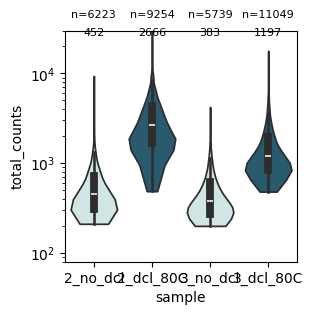

In [ ]:
### BC001: patient 2 no dcl
### BC002: patient 3 no dcl
### BC003: patient 2 dcl 80C
### BC004: patient 3 dcl 80C

for BC in ['BC001','BC002','BC003','BC004']: 
    adata = sc.read_10x_h5(f'{large_data_dir}/FFPE_decrosslink_additional_patients/{BC}_sample_filtered_feature_bc_matrix.h5')
    adata.obs['BC'] = BC
    if BC == 'BC001':
        combined_adata = adata
    else:
        combined_adata = combined_adata.concatenate(adata, join='outer')

sc.pp.calculate_qc_metrics(combined_adata, inplace=True)

combined_adata.obs['sample'] = combined_adata.obs['BC'].map({'BC001':'2_no_dcl', 'BC002':'3_no_dcl','BC003':'2_dcl_80C','BC004':'3_dcl_80C'})
combined_adata.obs['sample'] = combined_adata.obs['sample'].astype('category')
combined_adata.obs['sample'] = combined_adata.obs['sample'].cat.reorder_categories(['2_no_dcl', '2_dcl_80C', '3_no_dcl', '3_dcl_80C'])

fig, ax = plt.subplots(figsize=(3,3))
colors = ["#cfe8e8","#8fcfd1", "#4aa6b5","#1f5f78"]  

palette = {'2_no_dcl':colors[0], '3_no_dcl':colors[0],'2_dcl_80C':colors[3],'3_dcl_80C':colors[3]}
sc.pl.violin(combined_adata, ['total_counts'], groupby='sample', stripplot=False, inner='box', show=False, ax=ax, palette=palette)
ax.set_yscale('log')

for i, category in enumerate(combined_adata.obs['sample'].cat.categories):
    median_val = combined_adata.obs[combined_adata.obs['sample'] == category]['total_counts'].median()
    ax.text(i, 10**(4.4), f'{median_val:.0f}', ha='center', va='bottom', fontsize=8)
    n_cells = combined_adata.obs[combined_adata.obs['sample'] == category].shape[0]
    ax.text(i, 10**(4.6), f'n={n_cells}', ha='center', va='bottom', fontsize=8)

ax.set_ylim(80,3e4)
plt.savefig('../plots/WTA_counts_replicate_dcl_conditions.pdf', bbox_inches='tight')